In [1]:
# Residual Network for ERA5 Wave Spectra (MSE Loss Only)
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load processed data
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30) - INCLUDED
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30) - INCLUDED
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")   # NEW
print(f"b2: {b2.shape}")   # NEW

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")

print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in b2: {np.isnan(b2).sum()}")  # NEW

print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")  # NEW
print(f"NaN values in b1: {np.isnan(b1).sum()}")

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in b2: 0
NaN values in a1: 0
NaN values in a2: 0
NaN values in b1: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2532\3425270946.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [2]:
# Compute baseline reconstruction using directional moments
print("Computing baseline spectrum reconstruction...")

def compute_baseline_spectrum(S1D, a1, b1, n_dir=24):
    """Reconstruct 2D spectrum from 1D spectrum and directional moments"""
    # Use exact same directional grid as in preprocessing
    direction_deg = 7.5 + 15 * np.arange(n_dir)  # ERA5 directions: 7.5°, 22.5°, ..., 352.5°
    theta = np.deg2rad(direction_deg)
    ddir = np.deg2rad(15.0)  # 15° spacing
    
    # Initialize output
    S_baseline = np.zeros((S1D.shape[0], S1D.shape[1], n_dir))
    
    for i in range(S1D.shape[0]):
        for j in range(S1D.shape[1]):
            if S1D[i, j] > 1e-15:  # Only process non-zero frequencies
                # Correct first-harmonic directional distribution formula
                D = (1/(2*np.pi)) * (1 + 2*a1[i, j] * np.cos(theta) + 2*b1[i, j] * np.sin(theta))
                
                # Ensure non-negative
                D = np.maximum(D, 0)
                
                # Normalize using discrete integration
                integral = np.sum(D) * ddir
                if integral > 1e-10:
                    D = D / integral
                else:
                    D = np.ones(n_dir) / n_dir  # Uniform if coefficients invalid
                
                # Multiply by 1D spectrum
                S_baseline[i, j, :] = S1D[i, j] * D
    
    return S_baseline

Computing baseline spectrum reconstruction...


In [ ]:


# Compute baseline reconstruction
S_baseline = compute_baseline_spectrum(S1D, a1, b1)

# Compute residuals (what the ML model will learn)
residuals = S2D - S_baseline

print(f"Baseline shape: {S_baseline.shape}")
print(f"Residuals shape: {residuals.shape}")
print(f"Baseline energy: {np.mean(np.sum(S_baseline, axis=(1,2))):.4f}")
print(f"Original energy: {np.mean(np.sum(S2D, axis=(1,2))):.4f}")
print(f"Residual energy: {np.mean(np.sum(residuals, axis=(1,2))):.4f}")

# Check for NaN in computed arrays
print(f"NaN in baseline: {np.isnan(S_baseline).sum()}")
print(f"NaN in residuals: {np.isnan(residuals).sum()}")

Computing baseline spectrum reconstruction...
Baseline shape: (9504, 30, 24)
Residuals shape: (9504, 30, 24)
Baseline energy: 18.5994
Original energy: 18.5994
Residual energy: 0.0000
NaN in baseline: 0
NaN in residuals: 0


In [4]:
# Prepare inputs for ML model
print("Preparing inputs for ML model...")

# Create model inputs by concatenating ALL features
# Input features: S1D (30) + a1 (30) + b1 (30) + a2 (30) + b2 (30) = 150 features
batch_size, n_freq, n_dir = S2D.shape
n_features = n_freq * 5  # ALL 5 components

# Flatten and concatenate ALL inputs
inputs = np.concatenate([
    S1D.reshape(batch_size, -1),  # Shape: (batch_size, 30)  
    a1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    b1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    a2.reshape(batch_size, -1),   # Shape: (batch_size, 30) - NEW
    b2.reshape(batch_size, -1)    # Shape: (batch_size, 30) - NEW
], axis=1)  # Final shape: (batch_size, 150)

# Target is the residual (what to add to baseline)
targets = residuals.reshape(batch_size, -1)  # Shape: (batch_size, 30*24=720)

print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Check for any remaining NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=1)
    target_mask = ~np.isnan(targets).any(axis=1)
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    S_baseline = S_baseline[valid_mask]
    a2 = a2[valid_mask]  # Keep for potential future use
    b2 = b2[valid_mask]  # Keep for potential future use
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")

print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for ML model...
Input shape: (9504, 150)
Target shape: (9504, 720)
NaN in inputs: 0
NaN in targets: 0
Input range: [-0.991445, 22.504860]
Target range: [-4.785140, 14.124423]
Input mean: -0.121308, std: 0.506509
Input mean: -0.121308, std: 0.506509
Target mean: 0.000000, std: 0.117018
Target mean: 0.000000, std: 0.117018


In [5]:
# Normalize inputs and split data
print("Normalizing inputs and splitting data...")

# Normalize inputs to improve training stability
input_mean = inputs.mean(axis=0, keepdims=True)
input_std = inputs.std(axis=0, keepdims=True) + 1e-8  # Add small epsilon for numerical stability
inputs_norm = (inputs - input_mean) / input_std

# Save normalization parameters for later evaluation (proper deployment practice)
os.makedirs("models", exist_ok=True)
np.savez("models/mlp_res_normalization.npz", input_mean=input_mean, input_std=input_std)
print(f"💾 Saved normalization parameters to models/mlp_res_normalization.npz")

# For targets, use raw residuals without scaling
# This preserves energy consistency during reconstruction
targets_norm = targets
target_scale = 1.0  # No scaling applied

print(f"Input normalization - Mean: {input_mean.mean():.6f}, Std: {input_std.mean():.6f}")
print(f"Target scaling factor: {target_scale:.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")
print(f"Normalized target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Shuffle data before splitting
indices = np.random.permutation(n_samples)
train_idx = indices[:n_train]
# Split data chronologically (proper for time-series wave data)
# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Also split baseline spectra for evaluation
S2D_train = S2D[train_idx]
S2D_val = S2D[val_idx]
S2D_test = S2D[test_idx]
S_baseline_train = S_baseline[train_idx]
S_baseline_val = S_baseline[val_idx]  
S_baseline_test = S_baseline[test_idx]

print(f"Data splits:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Val: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

Normalizing inputs and splitting data...
💾 Saved normalization parameters to models/mlp_res_normalization.npz
Input normalization - Mean: -0.121308, Std: 0.339513
Target scaling factor: 1.000000
Normalized input range: [-8.264766, 23.587287]
Normalized target range: [-4.785140, 14.124423]
Data splits:
Train: 6652 samples
Val: 1425 samples
Test: 1427 samples
Using device: cpu


In [3]:
# Define model architecture
class ResidualNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, dropout_rate=0.1):
        super(ResidualNetwork, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Input layer
        self.input_layer = nn.Linear(input_size, hidden_size)
        
        # Hidden layers with residual connections
        self.hidden_layers = nn.ModuleList()
        for _ in range(num_layers):
            self.hidden_layers.append(nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(hidden_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
            ))
        
        # Output layer
        self.output_layer = nn.Linear(hidden_size, output_size)
        
        # Initialize weights carefully
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Xavier initialization for better gradient flow
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # Input layer
        x = torch.relu(self.input_layer(x))
        
        # Hidden layers with residual connections
        for layer in self.hidden_layers:
            residual = x
            x = layer(x)
            x = torch.relu(x + residual)  # Residual connection
        
        # Output layer (no activation for regression)
        x = self.output_layer(x)
        
        return x



In [ ]:
# Create model  
input_size = X_train.shape[1]   # 150 features (S1D + a1 + b1 + a2 + b2)
hidden_size = 256               # Reduced from 512 for stability
output_size = y_train.shape[1]  # 720 outputs (30 freq × 24 dir)
num_layers = 2                  # Reduced complexity

model = ResidualNetwork(input_size, hidden_size, output_size, num_layers).to(device)

print(f"Model created:")
print(f"Input size: {input_size}")
print(f"Hidden size: {hidden_size}")  
print(f"Output size: {output_size}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass with small batch to check for issues
test_batch = X_train_t[:4]  # Small test batch
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("Model architecture defined successfully")

In [4]:
# Define loss functions and helper functions
def reconstruct_2d_spectrum(residuals, baseline_flat, target_scale, batch_size, n_freq=30, n_dir=24):
    """Simple reconstruction from predicted residuals"""
    # Denormalize residuals
    residuals_scaled = residuals * target_scale
    
    # Reshape to 2D spectrum format
    residuals_2d = residuals_scaled.reshape(batch_size, n_freq, n_dir)
    baseline_2d = baseline_flat.reshape(batch_size, n_freq, n_dir)
    
    # Add residuals to baseline
    reconstructed = baseline_2d + residuals_2d
    
    # Enforce non-negativity
    reconstructed = torch.clamp(reconstructed, min=0.0)
    
    return reconstructed

In [ ]:


# Test simple reconstruction
print("Testing reconstruction function...")
with torch.no_grad():
    # Create test tensors
    test_residuals = model(X_train_t[:4])
    test_baseline = torch.FloatTensor(S_baseline_train[:4].reshape(4, -1)).to(device)
    test_target_2d = torch.FloatTensor(S2D_train[:4]).to(device)
    
    # Reconstruct spectrum
    test_recon = reconstruct_2d_spectrum(test_residuals, test_baseline, target_scale, 4)
    
    # Compute simple MSE loss
    mse_loss = torch.mean((test_recon - test_target_2d)**2)
    
    print(f"Test MSE loss: {mse_loss.item():.6f}")
    print(f"Reconstruction range: [{test_recon.min().item():.6f}, {test_recon.max().item():.6f}]")
    
    # Check for NaN in loss
    if torch.isnan(mse_loss):
        print("WARNING: NaN in loss function!")
    else:
        print("Reconstruction function working correctly")

print("Functions defined successfully")

Testing reconstruction function...
Test MSE loss: 0.452930
Reconstruction range: [0.000000, 3.360576]
Reconstruction function working correctly
Functions defined successfully


In [8]:
# Training setup
print("Setting up training...")

# Prepare baseline arrays as tensors for training
S_baseline_train_t = torch.FloatTensor(S_baseline_train.reshape(len(S_baseline_train), -1)).to(device)
S_baseline_val_t = torch.FloatTensor(S_baseline_val.reshape(len(S_baseline_val), -1)).to(device)
S2D_train_t = torch.FloatTensor(S2D_train).to(device)
S2D_val_t = torch.FloatTensor(S2D_val).to(device)

# Training hyperparameters
learning_rate = 1e-4    # Conservative learning rate
batch_size = 32         # Small batch size for stability
num_epochs = 50         # Moderate number of epochs
weight_decay = 1e-5     # L2 regularization

# Create data loaders with baseline and target data included
train_dataset = TensorDataset(X_train_t, y_train_t, S_baseline_train_t, S2D_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t, S_baseline_val_t, S2D_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

# MSE loss function
criterion = nn.MSELoss()

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Loss function: MSE only (no physics constraints)")

# Training history
train_losses = []

val_losses = []
print("Ready to start training")

best_val_loss = float('inf')

Setting up training...
Training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Train batches: 208
  Val batches: 45
  Loss function: MSE only (no physics constraints)
Ready to start training


In [9]:
# Training loop
model_path = "models/mlp_res.pth"  # Path to save the best model

print("Starting training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y, batch_baseline, batch_target_2d) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        residuals_pred = model(batch_x)
        
        # Reconstruct 2D spectrum
        reconstructed = reconstruct_2d_spectrum(
            residuals_pred, batch_baseline, target_scale, 
            batch_x.shape[0]
        )
        
        # Compute MSE loss
        loss = criterion(reconstructed, batch_target_2d)
        
        # Check for NaN 
        if torch.isnan(loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  Residuals range: [{residuals_pred.min().item():.6f}, {residuals_pred.max().item():.6f}]")
            print(f"  Reconstructed range: [{reconstructed.min().item():.6f}, {reconstructed.max().item():.6f}]")
            break
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check for NaN gradients
        grad_norms = [p.grad.norm().item() if p.grad is not None else 0 for p in model.parameters()]
        if any(np.isnan(gn) for gn in grad_norms):
            print(f"NaN gradients detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y, batch_baseline, batch_target_2d) in enumerate(val_loader):
            # Forward pass
            residuals_pred = model(batch_x)
            
            # Reconstruct 2D spectrum
            reconstructed = reconstruct_2d_spectrum(
                residuals_pred, batch_baseline, target_scale,
                batch_x.shape[0]
            )
            
            # Compute MSE loss
            loss = criterion(reconstructed, batch_target_2d)
            
            if not torch.isnan(loss):
                epoch_val_loss += loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.6f}")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  New best model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 50)

print("Training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting training...
  Batch 50/208, Loss: 0.064659
  Batch 100/208, Loss: 0.024177
  Batch 150/208, Loss: 0.026777
  Batch 200/208, Loss: 0.052622
Epoch 1/50
  Train Loss: 0.073545
  Val Loss: 0.021732
  Learning Rate: 1.00e-04
  New best model saved (val_loss: 0.021732)
--------------------------------------------------
  Batch 50/208, Loss: 0.051266
  Batch 100/208, Loss: 0.008054
  Batch 150/208, Loss: 0.009772
  Batch 200/208, Loss: 0.030469
Epoch 2/50
  Train Loss: 0.014116
  Val Loss: 0.016520
  Learning Rate: 1.00e-04
  New best model saved (val_loss: 0.016520)
--------------------------------------------------
  Batch 50/208, Loss: 0.006465
  Batch 100/208, Loss: 0.005763
  Batch 150/208, Loss: 0.007825
  Batch 200/208, Loss: 0.007864
Epoch 3/50
  Train Loss: 0.009918
  Val Loss: 0.014615
  Learning Rate: 1.00e-04
  New best model saved (val_loss: 0.014615)
--------------------------------------------------
  Batch 50/208, Loss: 0.005379
  Batch 100/208, Loss: 0.020270
  Batch

In [10]:
# Model evaluation 
print("Evaluating trained model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Prepare test data
S_baseline_test_t = torch.FloatTensor(S_baseline_test.reshape(len(S_baseline_test), -1)).to(device)
S2D_test_t = torch.FloatTensor(S2D_test).to(device)

# Make predictions on test set
with torch.no_grad():
    test_residuals = model(X_test_t)
    test_reconstructed = reconstruct_2d_spectrum(
        test_residuals, S_baseline_test_t, target_scale, len(X_test_t)
    )

# Convert back to numpy for evaluation
test_reconstructed_np = test_reconstructed.cpu().numpy()
test_target_np = S2D_test

# Compute reconstruction errors
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    
    # Relative error
    rel_error = np.abs(pred - target) / target_safe
    
    # Weight by spectral energy to focus on significant frequencies
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    
    return np.mean(weighted_error)

# Baseline error (moments-only reconstruction vs. true spectrum)
baseline_error = compute_relative_error(S_baseline_test, S2D_test)

# ML model error (ML reconstruction vs. true spectrum)  
ml_error = compute_relative_error(test_reconstructed_np, test_target_np)

# Residual learning improvement
residuals_only_error = compute_relative_error(S_baseline_test, S2D_test)  # Without ML correction

# L2 norm error calculation (matching mem_1.py approach)
print("Computing L2 norm errors...")

# Remove NaN values for error computation
y_true_clean = np.nan_to_num(test_target_np, nan=0.0)
S_baseline_clean = np.nan_to_num(S_baseline_test, nan=0.0)
S_ml_clean = np.nan_to_num(test_reconstructed_np, nan=0.0)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

# L2 errors for baseline
norm_true = np.linalg.norm(y_true_clean.reshape(n_time, -1), axis=1)
norm_diff_baseline = np.linalg.norm((S_baseline_clean - y_true_clean).reshape(n_time, -1), axis=1)
relative_l2_error_baseline = norm_diff_baseline / (norm_true + epsilon_l2)
l2_baseline_error = np.mean(relative_l2_error_baseline)

# L2 errors for ML model
norm_diff_ml = np.linalg.norm((S_ml_clean - y_true_clean).reshape(n_time, -1), axis=1)
relative_l2_error_ml = norm_diff_ml / (norm_true + epsilon_l2)
l2_ml_error = np.mean(relative_l2_error_ml)

print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"Baseline error (moments only):     {baseline_error:.6f}")
print(f"ML model error (with residuals):   {ml_error:.6f}")
print(f"Improvement factor:                {baseline_error/ml_error:.4f}x")
print(f"Relative improvement:              {(baseline_error-ml_error)/baseline_error*100:.2f}%")

print("\nL2 NORM ERROR:")
print(f"Baseline L2 error (moments only):  {l2_baseline_error:.6f}")
print(f"ML model L2 error (with residuals): {l2_ml_error:.6f}")
print(f"L2 improvement factor:             {l2_baseline_error/l2_ml_error:.4f}x")
print(f"L2 relative improvement:           {(l2_baseline_error-l2_ml_error)/l2_baseline_error*100:.2f}%")

# Additional statistics
print(f"\nDetailed statistics:")
print(f"Test set size:                     {len(test_target_np)} samples")
print(f"Mean target energy:                {np.mean(np.sum(test_target_np, axis=(1,2))):.6f}")
print(f"Mean ML energy:                    {np.mean(np.sum(test_reconstructed_np, axis=(1,2))):.6f}")
print(f"Mean baseline energy:              {np.mean(np.sum(S_baseline_test, axis=(1,2))):.6f}")

print(f"\nL2 error statistics:")
print(f"Baseline L2 - Mean: {np.mean(relative_l2_error_baseline):.6f}, Std: {np.std(relative_l2_error_baseline):.6f}")
print(f"ML model L2 - Mean: {np.mean(relative_l2_error_ml):.6f}, Std: {np.std(relative_l2_error_ml):.6f}")
print(f"Baseline L2 - Min: {np.min(relative_l2_error_baseline):.6f}, Max: {np.max(relative_l2_error_baseline):.6f}")
print(f"ML model L2 - Min: {np.min(relative_l2_error_ml):.6f}, Max: {np.max(relative_l2_error_ml):.6f}")

# Energy conservation check
energy_conservation = np.abs(
    np.mean(np.sum(test_reconstructed_np, axis=(1,2))) - np.mean(np.sum(test_target_np, axis=(1,2)))
) / np.mean(np.sum(test_target_np, axis=(1,2)))

print(f"Energy conservation error:         {energy_conservation:.6f}")

# Success criteria
TARGET_ERROR = 0.665  # Baseline error from previous results
SUCCESS_THRESHOLD = 0.9  # Must beat baseline by at least 10%

success = ml_error < TARGET_ERROR * SUCCESS_THRESHOLD

print(f"\nSuccess criteria:")
print(f"Target error (baseline):           {TARGET_ERROR:.6f}")
print(f"Success threshold (90% of baseline): {TARGET_ERROR * SUCCESS_THRESHOLD:.6f}")
print(f"Achieved error:                    {ml_error:.6f}")
print(f"SUCCESS: {'✓' if success else '✗'}")

if success:
    print("\n🎉 Model successfully improved upon baseline reconstruction!")
else:
    print("\n⚠️  Model did not achieve target improvement. Consider:")
    print("   - Increasing model complexity or training time")
    print("   - Adjusting loss function weights")
    print("   - Using different normalization or preprocessing")

print("="*60)

Evaluating trained model...
Computing L2 norm errors...

EVALUATION RESULTS
WEIGHTED ENERGY-BASED ERROR:
Baseline error (moments only):     0.667998
ML model error (with residuals):   0.519351
Improvement factor:                1.2862x
Relative improvement:              22.25%

L2 NORM ERROR:
Baseline L2 error (moments only):  0.651692
ML model L2 error (with residuals): 0.597382
L2 improvement factor:             1.0909x
L2 relative improvement:           8.33%

Detailed statistics:
Test set size:                     1427 samples
Mean target energy:                27.796831
Mean ML energy:                    25.026665
Mean baseline energy:              27.796832

L2 error statistics:
Baseline L2 - Mean: 0.651692, Std: 0.090455
ML model L2 - Mean: 0.597382, Std: 0.761111
Baseline L2 - Min: 0.417198, Max: 0.857105
ML model L2 - Min: 0.095455, Max: 6.990429
Energy conservation error:         0.099658

Success criteria:
Target error (baseline):           0.665000
Success threshold (90% of

In [11]:
# R-squared (coefficient of determination) calculation
print("Computing R-squared values...")

# Flatten the 2D spectra for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_baseline_flat = S_baseline_test.flatten()  
y_pred_ml_flat = test_reconstructed_np.flatten()

# Calculate R-squared for baseline model
ss_res_baseline = np.sum((y_true_flat - y_pred_baseline_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_baseline = 1 - (ss_res_baseline / ss_tot)

# Calculate R-squared for ML model
ss_res_ml = np.sum((y_true_flat - y_pred_ml_flat) ** 2)
r2_ml = 1 - (ss_res_ml / ss_tot)

# Calculate R-squared improvement
r2_improvement = r2_ml - r2_baseline

print("\n" + "="*40)
print("R-SQUARED ANALYSIS")
print("="*40)
print(f"Baseline R²:           {r2_baseline:.6f}")
print(f"ML Model R²:           {r2_ml:.6f}")
print(f"R² Improvement:        {r2_improvement:.6f}")
print(f"R² Improvement (%):    {r2_improvement/abs(r2_baseline)*100:.2f}%")

# Interpretation
if r2_ml > r2_baseline:
    print(f"\n✓ ML model explains {(r2_ml - r2_baseline)*100:.2f}% more variance than baseline")
else:
    print(f"\n⚠ ML model explains {abs(r2_ml - r2_baseline)*100:.2f}% less variance than baseline")

# Additional R-squared statistics
print(f"\nVariance explained:")
print(f"  Baseline: {r2_baseline*100:.2f}% of total variance")
print(f"  ML Model: {r2_ml*100:.2f}% of total variance")

# Correlation coefficients  
corr_baseline = np.corrcoef(y_true_flat, y_pred_baseline_flat)[0, 1]
corr_ml = np.corrcoef(y_true_flat, y_pred_ml_flat)[0, 1]

print(f"\nPearson correlations:")
print(f"  Baseline: {corr_baseline:.6f}")
print(f"  ML Model: {corr_ml:.6f}")

print("="*40)

Computing R-squared values...

R-SQUARED ANALYSIS
Baseline R²:           0.524034
ML Model R²:           0.873421
R² Improvement:        0.349387
R² Improvement (%):    66.67%

✓ ML model explains 34.94% more variance than baseline

Variance explained:
  Baseline: 52.40% of total variance
  ML Model: 87.34% of total variance

Pearson correlations:
  Baseline: 0.739306
  ML Model: 0.936739


# 🌊 Evaluation on Independent Dataset

Evaluate the trained MLP Residual model on completely separate evaluation data.

In [5]:
# Load evaluation dataset
model_path = "models/mlp_res.pth" 
print("Loading evaluation dataset...")

eval_data_path = "eval_data\\gum\\2019\\01\\processed_1\\era5_wave_eval.npz"
#eval_data_path = "data\processed\era5_wave_training.npz"

if not os.path.exists(eval_data_path):
    print(f"❌ Evaluation data not found: {eval_data_path}")
    print("Make sure to run process.py to create evaluation dataset first")
else:
    eval_data = np.load(eval_data_path)
    
    # Load evaluation data
    X_eval = eval_data["X"]          # (time, 5, 30) - [S1D, a1, b1, a2, b2]
    y_eval = eval_data["y"]          # (time, 30, 24) - True 2D spectrum
    freq_hz_eval = eval_data["freq_hz"]
    direction_deg_eval = eval_data["direction_deg"]
    
    print(f"✅ Evaluation data loaded successfully")
    print(f"  X_eval shape: {X_eval.shape}")
    print(f"  y_eval shape: {y_eval.shape}")
    print(f"  Time steps: {X_eval.shape[0]}")
    print(f"  Frequency bins: {len(freq_hz_eval)}")
    print(f"  Direction bins: {len(direction_deg_eval)}")
    
    # Extract components (same as training)
    S1D_eval = X_eval[:, 0, :]  # 1D spectrum: (time, 30)
    a1_eval = X_eval[:, 1, :]   # First harmonic a1: (time, 30)
    b1_eval = X_eval[:, 2, :]   # First harmonic b1: (time, 30)
    a2_eval = X_eval[:, 3, :]   # Second harmonic a2: (time, 30)
    b2_eval = X_eval[:, 4, :]   # Second harmonic b2: (time, 30)
    S2D_eval = y_eval           # 2D spectra: (time, 30, 24)
    
    print(f"  S1D_eval: {S1D_eval.shape}")
    print(f"  S2D_eval: {S2D_eval.shape}")
    
    # Check for NaN values
    print(f"  NaN values in X_eval: {np.isnan(X_eval).sum()}")
    print(f"  NaN values in y_eval: {np.isnan(y_eval).sum()}")

Loading evaluation dataset...
✅ Evaluation data loaded successfully
  X_eval shape: (744, 5, 30)
  y_eval shape: (744, 30, 24)
  Time steps: 744
  Frequency bins: 30
  Direction bins: 24
  S1D_eval: (744, 30)
  S2D_eval: (744, 30, 24)
  NaN values in X_eval: 0
  NaN values in y_eval: 0


In [6]:
# Preprocess evaluation data and create model
if 'X_eval' in locals():
    print("Preprocessing evaluation data...")
    
    # Prepare inputs exactly as in training
    batch_size_eval = S2D_eval.shape[0]
    
    # Use existing baseline computation function
    S_baseline_eval = compute_baseline_spectrum(S1D_eval, a1_eval, b1_eval)
    
    # Create model inputs (concatenate ALL features)
    inputs_eval = np.concatenate([
        S1D_eval.reshape(batch_size_eval, -1),  # Shape: (batch_size, 30)  
        a1_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        b1_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        a2_eval.reshape(batch_size_eval, -1),   # Shape: (batch_size, 30)
        b2_eval.reshape(batch_size_eval, -1)    # Shape: (batch_size, 30)
    ], axis=1)  # Final shape: (batch_size, 150)
    
    # Baseline and residuals for evaluation
    S_baseline_flat_eval = S_baseline_eval.reshape(batch_size_eval, -1)
    residuals_true_eval = (S2D_eval - S_baseline_eval).reshape(batch_size_eval, -1)
    
    print(f"  Input shape: {inputs_eval.shape}")
    print(f"  Baseline shape: {S_baseline_flat_eval.shape}")
    
    # Create model for evaluation
    input_size = 150               # S1D + a1 + b1 + a2 + b2 (30*5)
    hidden_size = 256              # Hidden layer size
    output_size = 720              # 30 freq × 24 dir (30*24)
    num_layers = 2                 # Number of residual layers
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResidualNetwork(input_size, hidden_size, output_size, num_layers).to(device)
    model_path = "models/mlp_res.pth"
    
    print(f"✅ Model created for evaluation")
    
    # Load normalization parameters
    normalization_path = "models/mlp_res_normalization.npz"
    
    if os.path.exists(normalization_path):
        print(f"  📂 Loading saved normalization parameters from {normalization_path}")
        norm_data = np.load(normalization_path)
        input_mean = norm_data['input_mean']
        input_std = norm_data['input_std']
        target_scale = float(norm_data.get('target_scale', 1.0))
        print(f"  ✅ Loaded normalization parameters")
    else:
        print(f"  ⚠️  Saved normalization not found, using evaluation data normalization")
        input_mean = inputs_eval.mean(axis=0, keepdims=True)
        input_std = inputs_eval.std(axis=0, keepdims=True) + 1e-8
        target_scale = np.std(residuals_true_eval)
        print(f"  ✅ Computed normalization from evaluation data")
    
    inputs_eval_norm = (inputs_eval - input_mean) / input_std
    
    print(f"  Applied normalization")
    print(f"  Normalized input range: [{inputs_eval_norm.min():.6f}, {inputs_eval_norm.max():.6f}]")
    
    # Convert to PyTorch tensor
    X_eval_t = torch.FloatTensor(inputs_eval_norm).to(device)
    
    print(f"  Converted to PyTorch tensor: {X_eval_t.shape}")
    
else:
    print("❌ Evaluation data not loaded. Run previous cell first.")

Preprocessing evaluation data...
  Input shape: (744, 150)
  Baseline shape: (744, 720)
✅ Model created for evaluation
  📂 Loading saved normalization parameters from models/mlp_res_normalization.npz
  ✅ Loaded normalization parameters
  Applied normalization
  Normalized input range: [-6.025949, 39.649116]
  Converted to PyTorch tensor: torch.Size([744, 150])


In [7]:
# Evaluate model on evaluation dataset
if 'model' in locals() and 'X_eval_t' in locals():
    
    print("Loading trained model...")
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint)
        print(f"  ✅ Model weights loaded from {model_path}")
    else:
        print(f"  ⚠️  Model not found at {model_path}")
    
    model.eval()
    
    with torch.no_grad():
        # Get residual predictions and reconstruct using existing function
        residual_pred_norm = model(X_eval_t)
        S_baseline_eval_t = torch.FloatTensor(S_baseline_eval.reshape(batch_size_eval, -1)).to(device)
        
        # Use existing reconstruct_2d_spectrum function
        S2D_pred_eval_t = reconstruct_2d_spectrum(residual_pred_norm, S_baseline_eval_t, target_scale, batch_size_eval)
        S2D_pred_eval = S2D_pred_eval_t.cpu().numpy()
        
        print(f"Model inference complete")
        print(f"  Reconstructed spectra shape: {S2D_pred_eval.shape}")
    
    # Compute evaluation metrics
    S2D_true_flat = S2D_eval.reshape(-1)
    S2D_pred_flat = S2D_pred_eval.reshape(-1) 
    
    # L2 Error
    mse = np.mean((S2D_true_flat - S2D_pred_flat) ** 2)
    rmse = np.sqrt(mse)
    
    # R-squared
    ss_res = np.sum((S2D_true_flat - S2D_pred_flat) ** 2)
    ss_tot = np.sum((S2D_true_flat - np.mean(S2D_true_flat)) ** 2)
    r2_score = 1 - (ss_res / ss_tot)
    
    print(f"\n📊 MLP Residual Model - Evaluation Results:")
    print(f"  MSE: {mse:.6e}")
    print(f"  RMSE: {rmse:.6e}")
    print(f"  R²: {r2_score:.6f}")
    
    # Store results for visualization  
    eval_results = {
        'S2D_true': S2D_eval,
        'S2D_pred': S2D_pred_eval,
        'S_baseline': S_baseline_eval,
        'mse': mse,
        'rmse': rmse,
        'r2': r2_score
    }
    
    print(f"\n✅ Results stored in eval_results dictionary")
    
else:
    print("❌ Model not available. Run previous cells first.")

Loading trained model...
  ✅ Model weights loaded from models/mlp_res.pth
Model inference complete
  Reconstructed spectra shape: (744, 30, 24)

📊 MLP Residual Model - Evaluation Results:
  MSE: 5.080703e-02
  RMSE: 2.254042e-01
  R²: 0.522400

✅ Results stored in eval_results dictionary


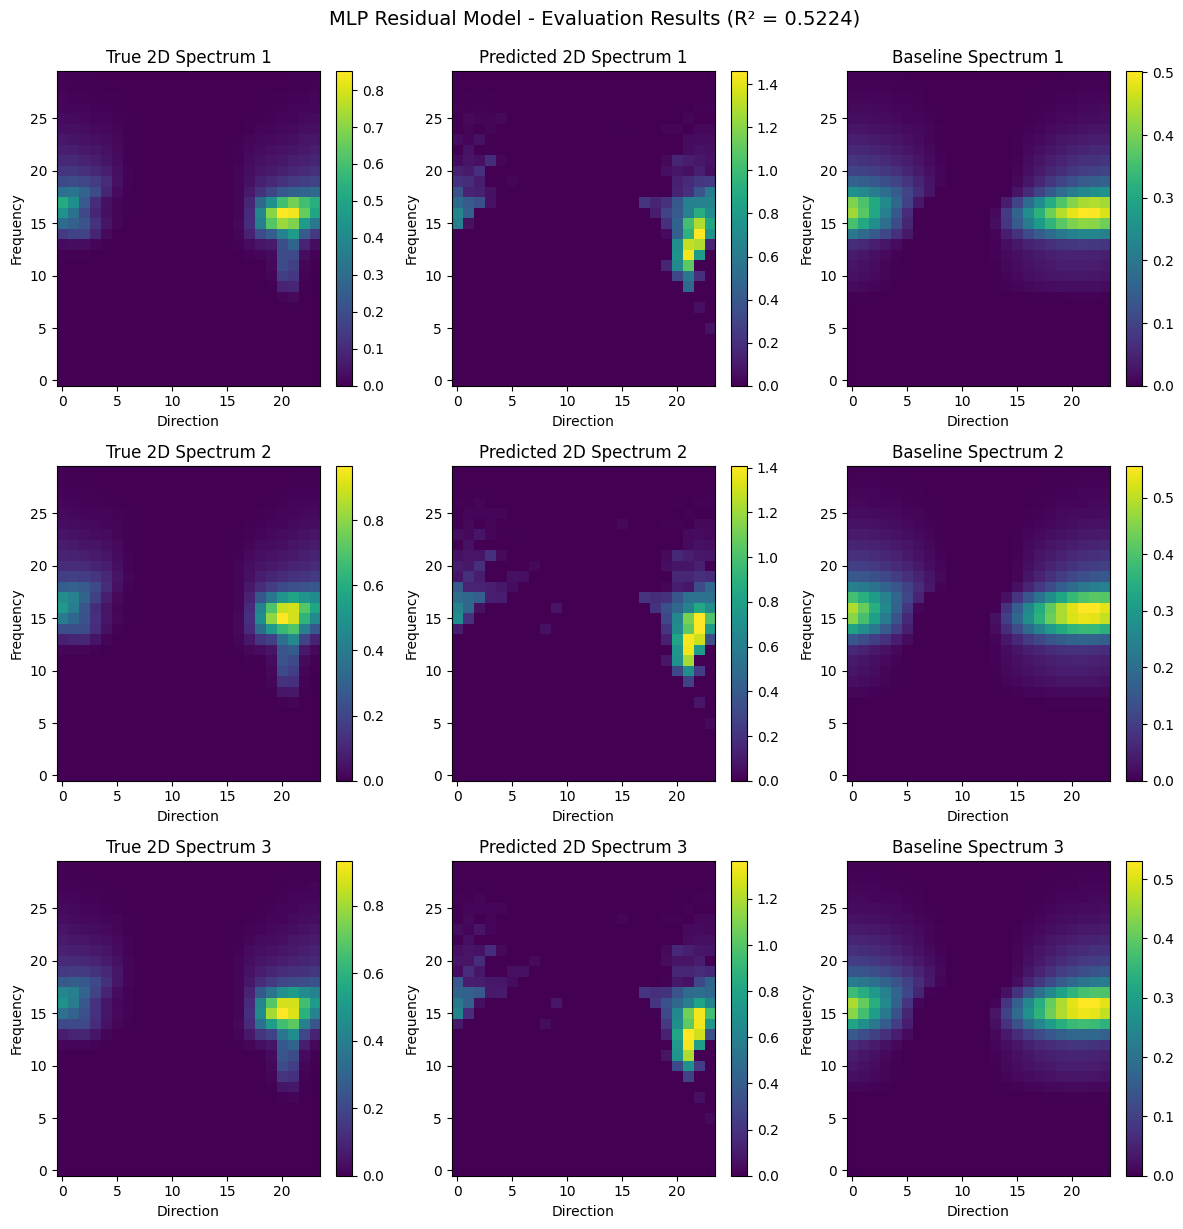

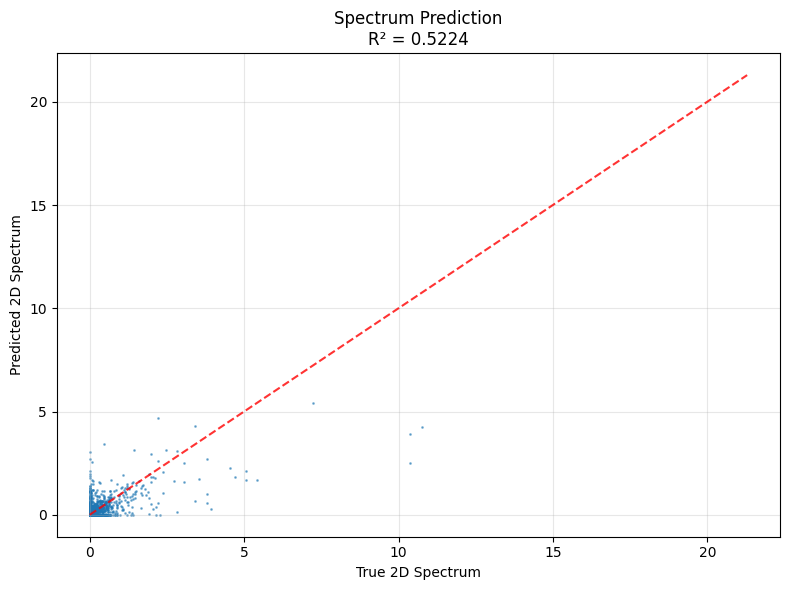


✅ Evaluation visualization complete!
Model performance: R² = 0.522400, RMSE = 2.254042e-01


In [8]:
# Visualize evaluation results with heatmaps
import matplotlib.pyplot as plt

if 'eval_results' in locals():
    
    # Select first few examples for visualization
    num_examples = min(3, eval_results['S2D_true'].shape[0])
    
    fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4*num_examples))
    if num_examples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_examples):
        # True 2D spectrum
        im1 = axes[i, 0].imshow(eval_results['S2D_true'][i], aspect='auto', cmap='viridis', 
                                origin='lower', interpolation='nearest')
        axes[i, 0].set_title(f'True 2D Spectrum {i+1}')
        axes[i, 0].set_xlabel('Direction')
        axes[i, 0].set_ylabel('Frequency')
        plt.colorbar(im1, ax=axes[i, 0])
        
        # Predicted 2D spectrum  
        im2 = axes[i, 1].imshow(eval_results['S2D_pred'][i], aspect='auto', cmap='viridis',
                                origin='lower', interpolation='nearest')
        axes[i, 1].set_title(f'Predicted 2D Spectrum {i+1}')
        axes[i, 1].set_xlabel('Direction')
        axes[i, 1].set_ylabel('Frequency')
        plt.colorbar(im2, ax=axes[i, 1])
        
        # Baseline spectrum
        im3 = axes[i, 2].imshow(eval_results['S_baseline'][i], aspect='auto', cmap='viridis',
                                origin='lower', interpolation='nearest')
        axes[i, 2].set_title(f'Baseline Spectrum {i+1}')
        axes[i, 2].set_xlabel('Direction')
        axes[i, 2].set_ylabel('Frequency')
        plt.colorbar(im3, ax=axes[i, 2])
    
    plt.tight_layout()
    plt.suptitle(f'MLP Residual Model - Evaluation Results (R² = {eval_results["r2"]:.4f})', 
                 fontsize=14, y=1.02)
    plt.show()
    
    # Create scatter plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Scatter plot for full spectra
    S2D_true_flat = eval_results['S2D_true'].reshape(-1)
    S2D_pred_flat = eval_results['S2D_pred'].reshape(-1)
    
    # Sample points for better visualization
    n_points = 10000
    indices = np.random.choice(len(S2D_true_flat), min(n_points, len(S2D_true_flat)), replace=False)
    
    ax.scatter(S2D_true_flat[indices], S2D_pred_flat[indices], alpha=0.5, s=1)
    min_val = min(S2D_true_flat.min(), S2D_pred_flat.min())
    max_val = max(S2D_true_flat.max(), S2D_pred_flat.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    ax.set_xlabel('True 2D Spectrum')
    ax.set_ylabel('Predicted 2D Spectrum')
    ax.set_title(f'Spectrum Prediction\nR² = {eval_results["r2"]:.4f}')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Evaluation visualization complete!")
    print(f"Model performance: R² = {eval_results['r2']:.6f}, RMSE = {eval_results['rmse']:.6e}")

else:
    print("❌ Evaluation results not available. Run previous cells first.")